# Notebook 01 — Image Processing Fundamentals

**Vision & 3D Mapping Workshop** | Block 1: Mathematical Foundations

---

## Why This Matters

Every perception pipeline in autonomous systems — from a drone's obstacle detector to a
self-driving car's lane tracker — begins with image processing. Before you can understand
Harris corner detection (Notebook 05), scale-invariant features (SIFT), or how CNNs extract
features for depth estimation (Notebook 09), you need to master the fundamental operations
on images.

**Key insight**: Convolution is the single operation shared by classical vision and deep
learning. Implementing it from scratch reveals that a Conv2D layer is just sliding a kernel
and computing dot products — but with *learned* kernels instead of hand-designed ones.

### What You'll Learn

1. Images as numerical arrays — grayscale, RGB, dtype conventions
2. **2D Convolution** — the fundamental operation (from scratch)
3. **Filtering** — Gaussian blur, Sobel gradients, Laplacian
4. **Edge Detection** — Canny detector, step by step
5. **Image Pyramids** — Gaussian and Laplacian pyramids for multi-scale analysis
6. **Morphological Operations** — erosion, dilation for depth map cleanup

### Prerequisites
- Linear algebra basics (matrix multiplication, eigenvalues)
- Python / NumPy familiarity

### References
- Szeliski, "Computer Vision: Algorithms and Applications" 2nd ed, Ch. 3
- Gonzalez & Woods, "Digital Image Processing", Ch. 3–4

In [1]:
import sys

sys.path.insert(0, "..")

import cv2
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["image.cmap"] = "gray"
np.set_printoptions(precision=4, suppress=True)

---
## 1. Images as Numerical Arrays

An image is a 2D (grayscale) or 3D (color) array of numbers:

| Property | Grayscale | Color (RGB) |
|----------|-----------|-------------|
| Shape | (H, W) | (H, W, 3) |
| uint8 range | [0, 255] | [0, 255] per channel |
| float32 range | [0.0, 1.0] | [0.0, 1.0] per channel |

**Convention note**: OpenCV loads images as BGR (not RGB). Matplotlib expects RGB.
We'll convert appropriately.

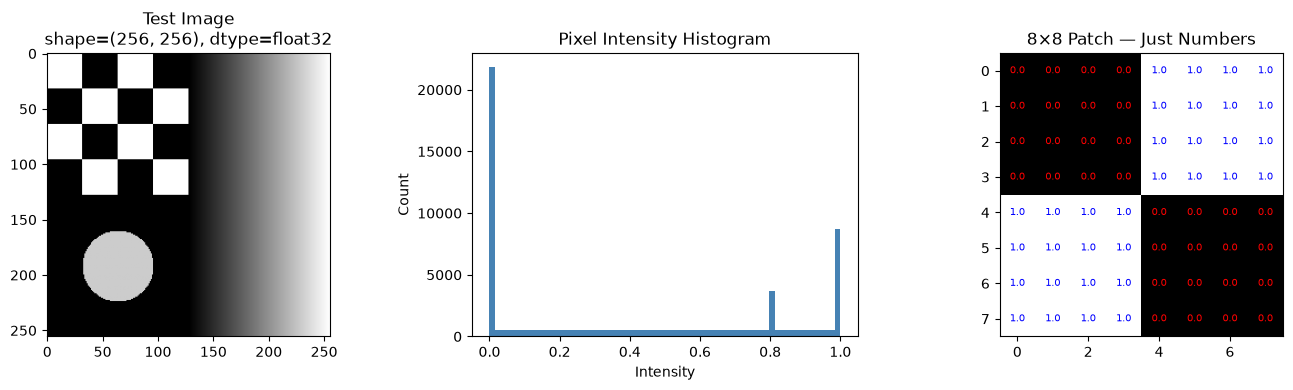

In [2]:
def generate_test_image(size=256):
    """Generate a synthetic test image with edges, corners, and gradients."""
    img = np.zeros((size, size), dtype=np.float32)

    # Checkerboard pattern (top-left quadrant)
    block = size // 8
    for i in range(4):
        for j in range(4):
            if (i + j) % 2 == 0:
                img[i * block : (i + 1) * block, j * block : (j + 1) * block] = 1.0

    # Gradient (right half)
    img[:, size // 2 :] = np.linspace(0, 1, size // 2)[np.newaxis, :]

    # Circle
    cy, cx = size * 3 // 4, size // 4
    Y, X = np.ogrid[:size, :size]
    mask = (X - cx) ** 2 + (Y - cy) ** 2 < (size // 8) ** 2
    img[mask] = 0.8

    return img


test_img = generate_test_image(256)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(test_img, cmap="gray")
axes[0].set_title(f"Test Image\nshape={test_img.shape}, dtype={test_img.dtype}")

axes[1].hist(test_img.ravel(), bins=64, color="steelblue", edgecolor="none")
axes[1].set_title("Pixel Intensity Histogram")
axes[1].set_xlabel("Intensity")
axes[1].set_ylabel("Count")

patch = test_img[60:68, 28:36]
axes[2].imshow(patch, cmap="gray", vmin=0, vmax=1)
for i in range(patch.shape[0]):
    for j in range(patch.shape[1]):
        axes[2].text(
            j,
            i,
            f"{patch[i, j]:.1f}",
            ha="center",
            va="center",
            fontsize=7,
            color="red" if patch[i, j] < 0.5 else "blue",
        )
axes[2].set_title("8×8 Patch — Just Numbers")
plt.tight_layout()
plt.show()

---
## 1.5  Convolution in 1D — Building Intuition

Before tackling 2D convolution on images, let's build intuition with the simpler **1D case**.

### Mathematical Definition

The discrete 1D convolution of a signal \(f\) with a kernel \(g\) of length \(2k+1\) is:

$$
(f * g)[n] = \sum_{m=-k}^{k} f[n - m] \cdot g[m]
$$

**Convolution vs. correlation.** True convolution flips the kernel (\(f[n-m]\)). **Cross-correlation** does not flip: \((f \star g)[n] = \sum_m f[n+m]\,g[m]\). For symmetric kernels (Gaussian, Laplacian) the two are identical. In practice, most implementations — including OpenCV's `filter2D` and PyTorch's `nn.Conv1d` — compute **correlation** (no flip). We follow this convention throughout.

**Step-by-step procedure:**
1. **Slide** the kernel across the signal, one position at a time
2. **Multiply** each kernel element with the overlapping signal element
3. **Sum** all the products → that's the output at this position

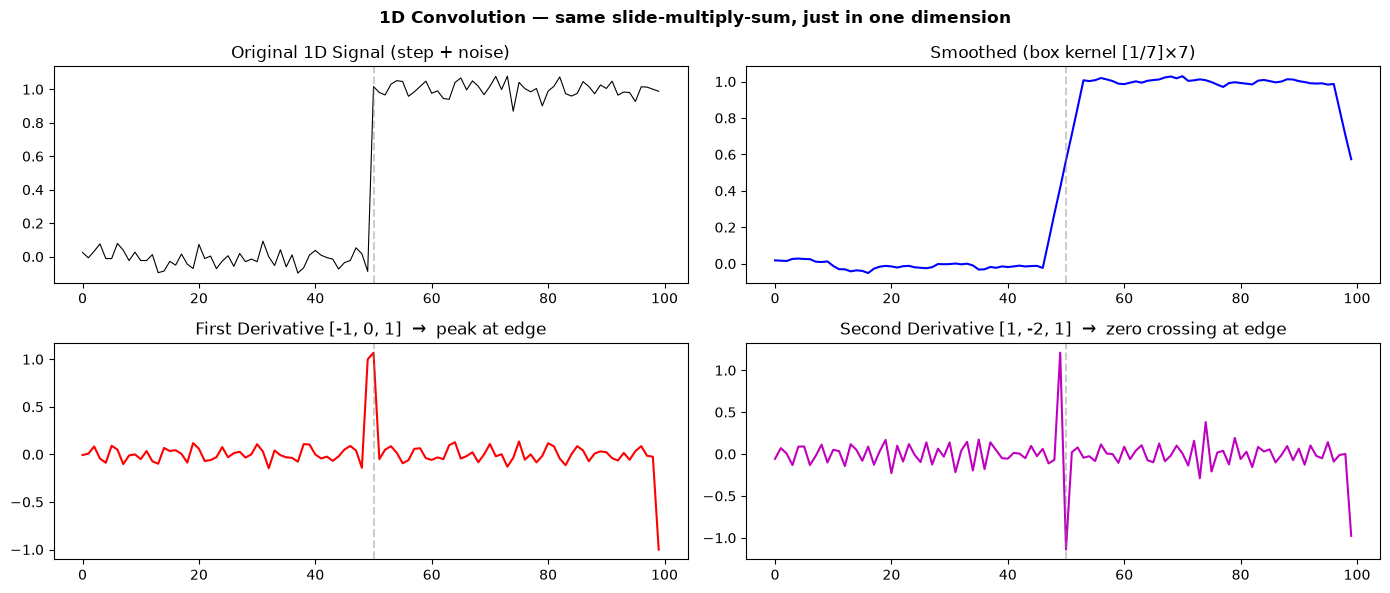

In [3]:
def convolve1d(signal: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    """
    1D convolution (correlation) with zero-padding.

    For each output position n:
        output[n] = Σ_m  signal[n + m] · kernel[m]
    """
    N = len(signal)
    K = len(kernel)
    pad = K // 2
    padded = np.pad(signal, pad, mode="constant")
    output = np.zeros(N)
    for n in range(N):
        output[n] = np.sum(padded[n : n + K] * kernel)
    return output


# --- Demo: smoothing and edge-detection in 1D ---
np.random.seed(42)
t = np.arange(100, dtype=np.float64)
signal_1d = np.where(t < 50, 0.0, 1.0) + np.random.normal(0, 0.05, size=100)

box_kernel = np.ones(7) / 7  # smoothing (moving average)
edge_kernel = np.array([-1.0, 0.0, 1.0])  # central-difference first derivative
second_deriv = np.array([1.0, -2.0, 1.0])  # second derivative (1D Laplacian)

smoothed_1d = convolve1d(signal_1d, box_kernel)
edges_1d = convolve1d(signal_1d, edge_kernel)
second_1d = convolve1d(signal_1d, second_deriv)

fig, axes = plt.subplots(2, 2, figsize=(14, 6))
axes[0, 0].plot(signal_1d, "k-", lw=0.8)
axes[0, 0].set_title("Original 1D Signal (step + noise)")

axes[0, 1].plot(smoothed_1d, "b-")
axes[0, 1].set_title("Smoothed (box kernel [1/7]×7)")

axes[1, 0].plot(edges_1d, "r-")
axes[1, 0].set_title("First Derivative [-1, 0, 1]  →  peak at edge")

axes[1, 1].plot(second_1d, "m-")
axes[1, 1].set_title("Second Derivative [1, -2, 1]  →  zero crossing at edge")

for ax in axes.flat:
    ax.axvline(50, color="gray", ls="--", alpha=0.4)
plt.suptitle(
    "1D Convolution — same slide-multiply-sum, just in one dimension", fontweight="bold"
)
plt.tight_layout()
plt.show()

---
## 2. 2D Convolution — The Fundamental Operation

### Mathematical Definition

The **discrete 2D convolution** of an image \(f\) with a kernel \(g\) is:

$$
(f * g)(x, y) = \sum_{i=-k}^{k} \sum_{j=-k}^{k} f(x - i,\, y - j) \cdot g(i, j)
$$

where \(k = \lfloor \text{kernel\_size} / 2 \rfloor\).

**Intuition**: The kernel slides over every pixel. At each position, we compute the
element-wise product of the kernel with the image patch underneath, then sum.

**Correlation vs Convolution**: In practice, most implementations compute *correlation*
(no kernel flip). True convolution flips the kernel 180°. For symmetric kernels
(Gaussian, Laplacian), it doesn't matter.

### Why This Matters for Deep Learning

A CNN layer does exactly this — but with **learned** kernels. The backpropagation
algorithm adjusts the kernel weights to minimize a loss function. When you implement
convolution by hand, you're implementing the forward pass of a Conv2D layer.

### Properties

- **Commutative**: \(f * g = g * f\)
- **Associative**: \((f * g) * h = f * (g * h)\) — chain of blurs = one bigger blur
- **Distributive**: \(f * (g + h) = f * g + f * h\)
- **Separable filters**: If \(g(x,y) = g_x(x) \cdot g_y(y)\), then 2D convolution
  decomposes into two 1D passes: \(O(n \cdot k^2) \to O(n \cdot 2k)\)
- **Convolution theorem**: In the frequency domain, convolution becomes
  pointwise multiplication: \(\mathcal{F}(f * g) = \mathcal{F}(f) \cdot \mathcal{F}(g)\).
  This means Gaussian blurring is a low-pass filter — high-frequency noise is
  attenuated while low-frequency structure is preserved.

### The Derivative Theorem of Convolution

A key property that makes convolution central to edge detection and feature
extraction:

$$\frac{\partial}{\partial x}(f * g) = f * \frac{\partial g}{\partial x} = \frac{\partial f}{\partial x} * g$$

**Consequence:** To compute the gradient of a noisy image, differentiate the
*kernel* rather than the image. This is why Sobel and Scharr filters combine
smoothing and differentiation into a single convolution — and why Canny edge
detection (Section 5) first smooths with a Gaussian, then differentiates.

Max difference between our convolution and cv2.filter2D: 2.98e-07


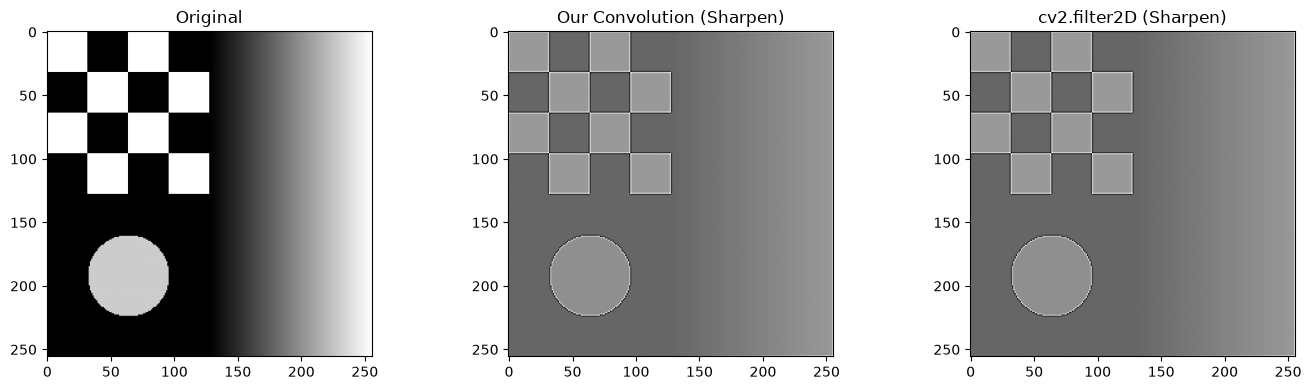

In [4]:
def convolve2d(image: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    """
    2D convolution from scratch (correlation, no kernel flip).

    For each output pixel (x, y):
        output(x, y) = Σ_i Σ_j  image(x+i, y+j) · kernel(i, j)

    where i, j range over the kernel dimensions centered at (0,0).

    Uses zero-padding so output has the same size as input.

    Parameters
    ----------
    image : (H, W) float array
    kernel : (kH, kW) float array, kH and kW should be odd

    Returns
    -------
    output : (H, W) float array
    """
    assert image.ndim == 2, "Input must be grayscale (H, W)"
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2

    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode="constant")
    H, W = image.shape
    output = np.zeros_like(image)

    for i in range(H):
        for j in range(W):
            patch = padded[i : i + kh, j : j + kw]
            output[i, j] = np.sum(patch * kernel)

    return output


# Verify against OpenCV
kernel_test = np.array(
    [[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=np.float32
)  # Sharpen
our_result = convolve2d(test_img, kernel_test)
cv2_result = cv2.filter2D(test_img, -1, kernel_test, borderType=cv2.BORDER_CONSTANT)

max_diff = np.max(np.abs(our_result - cv2_result))
print(f"Max difference between our convolution and cv2.filter2D: {max_diff:.2e}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(test_img)
axes[0].set_title("Original")
axes[1].imshow(our_result)
axes[1].set_title("Our Convolution (Sharpen)")
axes[2].imshow(cv2_result)
axes[2].set_title("cv2.filter2D (Sharpen)")
plt.tight_layout()
plt.show()

### Stride in Convolution

So far we've slid the kernel **one pixel at a time** (stride = 1). In practice — especially
in deep learning — we often use **stride > 1** to simultaneously convolve and downsample.

**Output size formula** (with zero-padding \(p\) on each side):

$$
\text{output\_size} = \left\lfloor \frac{\text{input\_size} - \text{kernel\_size} + 2p}{\text{stride}} \right\rfloor + 1
$$

With no padding (\(p = 0\)):

$$
\text{output\_size} = \left\lfloor \frac{\text{input\_size} - \text{kernel\_size}}{\text{stride}} \right\rfloor + 1
$$

**Why stride matters**:
- Stride-2 convolutions **replace pooling layers** in modern architectures (ResNet, U-Net, etc.)
- They reduce spatial dimensions while learning *what* to downsample
- A stride-2 conv with a 3×3 kernel halves the resolution — like max-pooling, but learnable

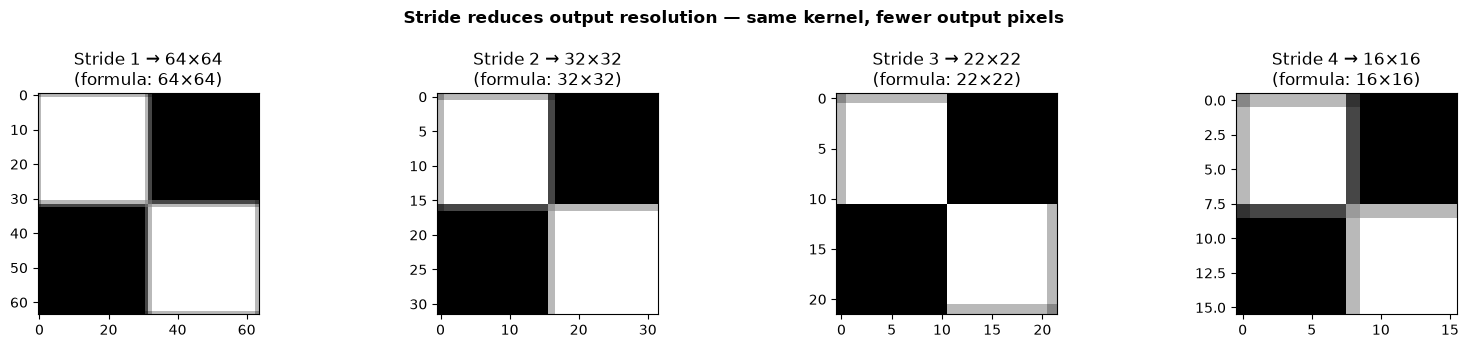

In [5]:
def gaussian_kernel(size: int, sigma: float) -> np.ndarray:
    """Generate a normalized 2D Gaussian kernel."""
    assert size % 2 == 1, "Kernel size must be odd"
    k = size // 2
    y, x = np.mgrid[-k : k + 1, -k : k + 1].astype(np.float64)
    kernel = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    return kernel / kernel.sum()


def convolve2d_strided(
    image: np.ndarray, kernel: np.ndarray, stride: int = 1
) -> np.ndarray:
    """
    2D convolution with configurable stride and same-padding.

    output_size = floor((input_size - kernel_size + 2*pad) / stride) + 1
    """
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2
    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode="constant")
    H, W = image.shape

    out_h = (H + 2 * pad_h - kh) // stride + 1
    out_w = (W + 2 * pad_w - kw) // stride + 1
    output = np.zeros((out_h, out_w))

    for i in range(out_h):
        for j in range(out_w):
            ii, jj = i * stride, j * stride
            output[i, j] = np.sum(padded[ii : ii + kh, jj : jj + kw] * kernel)
    return output


# Demonstrate how stride reduces output size
K = gaussian_kernel(3, 1.0)
small = test_img[:64, :64]

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, s in zip(axes, [1, 2, 3, 4], strict=False):
    out = convolve2d_strided(small, K, stride=s)
    expected = (64 - 3 + 2) // s + 1
    ax.imshow(out, cmap="gray")
    ax.set_title(
        f"Stride {s} → {out.shape[1]}×{out.shape[0]}\n(formula: {expected}×{expected})"
    )

plt.suptitle(
    "Stride reduces output resolution — same kernel, fewer output pixels",
    fontweight="bold",
)
plt.tight_layout()
plt.show()

---
## 3. The Gaussian Kernel

### Mathematical Definition

The 2D Gaussian function:

$$
G(x, y; \sigma) = \frac{1}{2\pi\sigma^2} \exp\!\left(-\frac{x^2 + y^2}{2\sigma^2}\right)
$$

**Properties**:
- **Isotropic**: same in all directions (circular level curves)
- **Separable**: \(G(x,y) = G(x) \cdot G(y)\) — a 2D Gaussian blur can be done as
  two 1D passes (horizontal then vertical), reducing \(O(k^2)\) to \(O(2k)\)

**Proof of separability.** Starting from the 2D Gaussian:

$$
G(x,y;\sigma) = \frac{1}{2\pi\sigma^2} \exp\!\left(-\frac{x^2 + y^2}{2\sigma^2}\right)
$$

Factor the normalization constant and use \(e^{a+b} = e^a \cdot e^b\):

$$
= \frac{1}{\sqrt{2\pi}\,\sigma} \cdot \frac{1}{\sqrt{2\pi}\,\sigma} \;\cdot\; \exp\!\left(-\frac{x^2}{2\sigma^2}\right) \exp\!\left(-\frac{y^2}{2\sigma^2}\right)
= \underbrace{\frac{1}{\sqrt{2\pi}\,\sigma}\exp\!\left(-\frac{x^2}{2\sigma^2}\right)}_{G_{1D}(x;\,\sigma)} \;\cdot\; \underbrace{\frac{1}{\sqrt{2\pi}\,\sigma}\exp\!\left(-\frac{y^2}{2\sigma^2}\right)}_{G_{1D}(y;\,\sigma)}
$$

Therefore \(G(x,y;\sigma) = G_{1D}(x;\sigma) \cdot G_{1D}(y;\sigma)\), so the 2D
convolution \(G * I\) decomposes into two successive 1D convolutions — first along
rows, then along columns — reducing cost per pixel from \(O(k^2)\) to \(O(2k)\). \(\square\)

- **The Gaussian is the ONLY kernel that doesn't introduce new structures** at
  coarser scales (Koenderink 1984, Lindeberg 1994). This is why scale-space theory
  uses Gaussians exclusively.

### Rule of Thumb
Kernel size ≈ \(\lceil 6\sigma \rceil\) (captures 99.7% of the distribution, the 3σ rule).

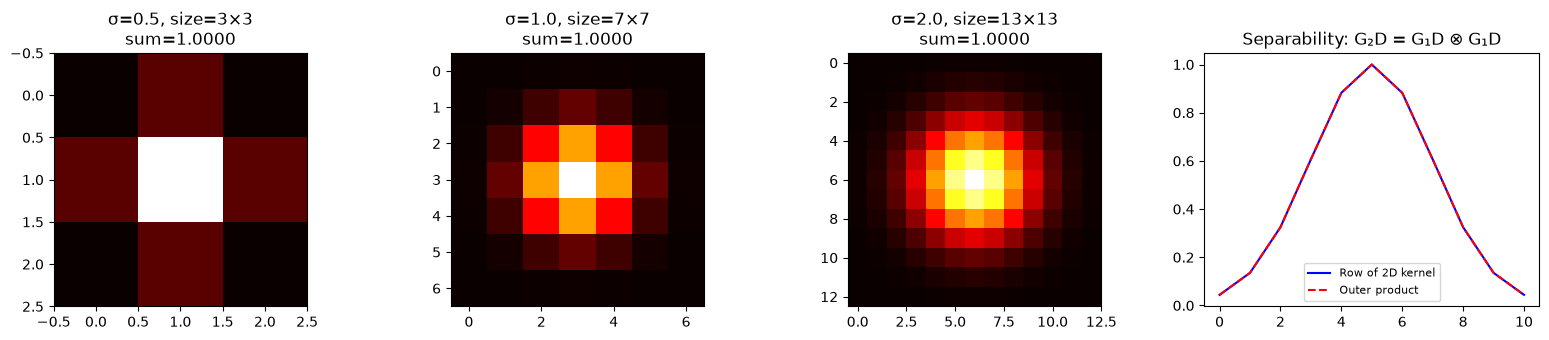

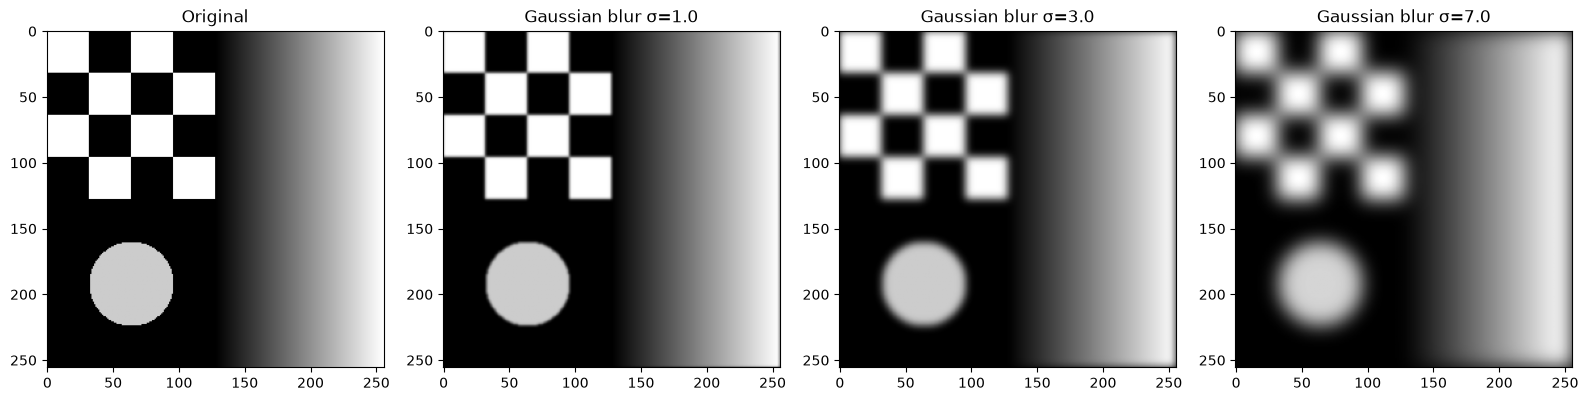

In [6]:
# Visualize Gaussian kernels at different sigmas (gaussian_kernel defined in Section 2)
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, sigma in zip(axes[:3], [0.5, 1.0, 2.0], strict=False):
    size = max(3, int(np.ceil(6 * sigma)) | 1)  # ensure odd
    G = gaussian_kernel(size, sigma)
    ax.imshow(G, cmap="hot", interpolation="nearest")
    ax.set_title(f"σ={sigma}, size={size}×{size}\nsum={G.sum():.4f}")

G_2d = gaussian_kernel(11, 2.0)
g_1d = G_2d[5, :]  # middle row
G_sep = np.outer(g_1d, g_1d)
G_sep /= G_sep.sum()
axes[3].plot(G_2d[5, :] / G_2d[5, :].max(), "b-", label="Row of 2D kernel")
axes[3].plot(G_sep[5, :] / G_sep[5, :].max(), "r--", label="Outer product")
axes[3].set_title("Separability: G₂D = G₁D ⊗ G₁D")
axes[3].legend(fontsize=8)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(test_img)
axes[0].set_title("Original")
for ax, sigma in zip(axes[1:], [1.0, 3.0, 7.0], strict=False):
    size = max(3, int(np.ceil(6 * sigma)) | 1)
    G = gaussian_kernel(size, sigma)
    blurred = convolve2d(test_img, G)
    ax.imshow(blurred)
    ax.set_title(f"Gaussian blur σ={sigma}")
plt.tight_layout()
plt.show()

---
## 4. Image Gradients — Sobel Operator

### Mathematical Foundation

The **image gradient** at pixel \((x, y)\) is the vector of partial derivatives:

$$
\nabla I(x, y) = \begin{bmatrix} \frac{\partial I}{\partial x} \\ \frac{\partial I}{\partial y} \end{bmatrix}
$$

Since images are discrete, we approximate derivatives with finite differences.
The **Sobel operator** combines differentiation with Gaussian smoothing:

$$
S_x = \begin{bmatrix} -1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1 \end{bmatrix}
= \begin{bmatrix} 1 \\ 2 \\ 1 \end{bmatrix}
\begin{bmatrix} -1 & 0 & 1 \end{bmatrix}
$$

Note the separability: Sobel = (smoothing in y) × (differentiation in x).

**Gradient magnitude** \(M\) and **direction** \(\theta\):

$$
M = \sqrt{G_x^2 + G_y^2}, \qquad \theta = \arctan\!\left(\frac{G_y}{G_x}\right)
$$

The gradient magnitude tells us *how strong* an edge is; the direction tells us
its *orientation* (perpendicular to the edge itself).

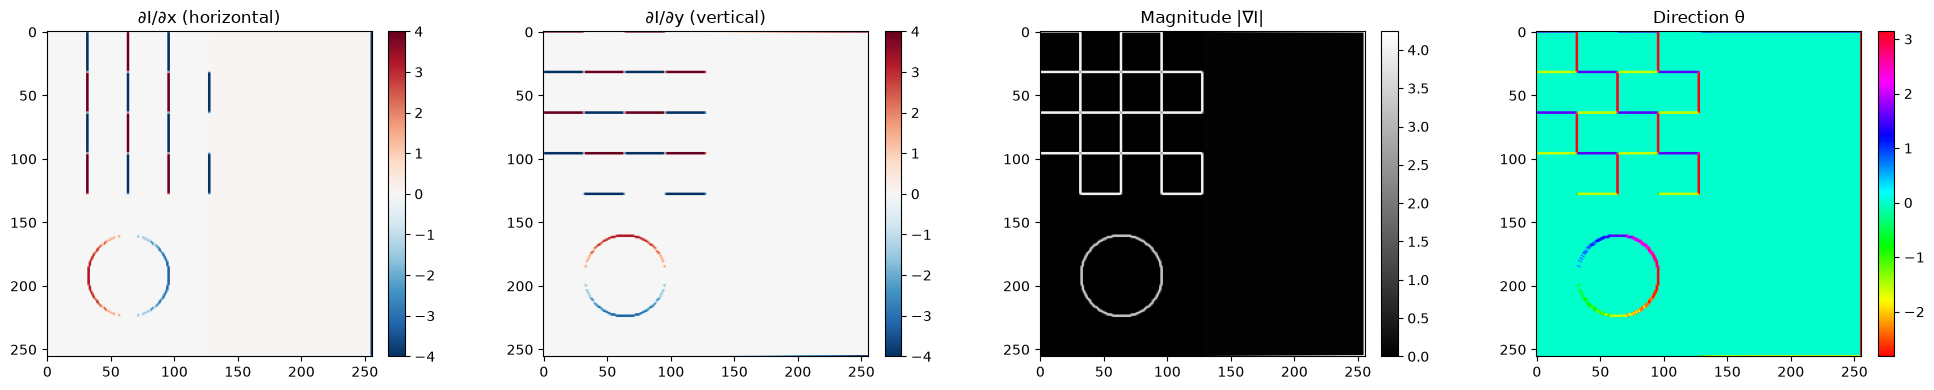

In [7]:
def sobel_gradients(image: np.ndarray):
    """
    Compute image gradients using Sobel operators.

    The Sobel operator approximates the image gradient by convolving
    with separable kernels that combine smoothing and differentiation:

        Gx ≈ Sx * I    (horizontal gradient)
        Gy ≈ Sy * I    (vertical gradient)

    Returns
    -------
    gx : horizontal gradient (∂I/∂x)
    gy : vertical gradient (∂I/∂y)
    magnitude : √(gx² + gy²)
    direction : arctan2(gy, gx) in radians [-π, π]
    """
    Sx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float64)
    Sy = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float64)

    gx = convolve2d(image.astype(np.float64), Sx)
    gy = convolve2d(image.astype(np.float64), Sy)
    magnitude = np.sqrt(gx**2 + gy**2)
    direction = np.arctan2(gy, gx)

    return gx, gy, magnitude, direction


gx, gy, mag, direction = sobel_gradients(test_img)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
titles = ["∂I/∂x (horizontal)", "∂I/∂y (vertical)", "Magnitude |∇I|", "Direction θ"]
images = [gx, gy, mag, direction]
cmaps = ["RdBu_r", "RdBu_r", "gray", "hsv"]
for ax, im, title, cmap in zip(axes, images, titles, cmaps, strict=False):
    mappable = ax.imshow(im, cmap=cmap)
    ax.set_title(title)
    plt.colorbar(mappable, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

---
### Laplacian Filter — Second-Order Edge Detection

The **Laplacian** is the sum of second partial derivatives:

$$
\nabla^2 I = \frac{\partial^2 I}{\partial x^2} + \frac{\partial^2 I}{\partial y^2}
$$

In 1D the second derivative is approximated by \([1,\, -2,\, 1]\) (as shown in Section 1.5).
In 2D, summing the second derivatives in \(x\) and \(y\) gives the discrete Laplacian kernel:

$$
\nabla^2 \approx \begin{bmatrix} 0 & 1 & 0 \\ 1 & -4 & 1 \\ 0 & 1 & 0 \end{bmatrix}
\quad \text{(4-connected)}, \qquad
\begin{bmatrix} 1 & 1 & 1 \\ 1 & -8 & 1 \\ 1 & 1 & 1 \end{bmatrix}
\quad \text{(8-connected)}
$$

**Edge detection via zero crossings**: The first derivative (Sobel) *peaks* at edges; the
second derivative (Laplacian) **crosses zero** at edges. Marr & Hildreth (1980) proposed
detecting edges as zero crossings of \(\nabla^2(G_\sigma * I)\) — the Laplacian of the
Gaussian-smoothed image (LoG).

**Connection to SIFT — DoG ≈ σ²∇²G derivation**: Taylor-expand \(G(x;\, k\sigma)\) around \(\sigma\):

$$
G(x;\, k\sigma) - G(x;\, \sigma) \approx (k-1)\,\sigma\,\frac{\partial G}{\partial \sigma}
$$

The 2D Gaussian \(G(x,y;\sigma) = \frac{1}{2\pi\sigma^2} e^{-r^2/(2\sigma^2)}\) (where \(r^2 = x^2 + y^2\)) satisfies the **heat equation** \(\frac{\partial G}{\partial \sigma} = \sigma\,\nabla^2 G\). We prove this by computing both sides.

**Left side** — differentiate \(G\) w.r.t. \(\sigma\) using the product rule on \(\sigma^{-2} e^{-r^2/(2\sigma^2)}\):

$$
\frac{\partial G}{\partial \sigma} = \frac{1}{2\pi}\left[\frac{-2}{\sigma^3}\,e^{-r^2/(2\sigma^2)} + \frac{1}{\sigma^2}\,e^{-r^2/(2\sigma^2)}\,\frac{r^2}{\sigma^3}\right] = G\!\left(\frac{-2}{\sigma} + \frac{r^2}{\sigma^3}\right)
$$

**Right side** — compute \(\nabla^2 G = \frac{\partial^2 G}{\partial x^2} + \frac{\partial^2 G}{\partial y^2}\). First:

$$
\frac{\partial G}{\partial x} = G\!\left(\frac{-x}{\sigma^2}\right), \qquad
\frac{\partial^2 G}{\partial x^2} = G\!\left(\frac{-1}{\sigma^2} + \frac{x^2}{\sigma^4}\right)
$$

and similarly for \(y\). Summing:

$$
\nabla^2 G = G\!\left(\frac{-2}{\sigma^2} + \frac{r^2}{\sigma^4}\right)
\qquad \Longrightarrow \qquad
\sigma\,\nabla^2 G = G\!\left(\frac{-2}{\sigma} + \frac{r^2}{\sigma^3}\right) = \frac{\partial G}{\partial \sigma} \quad \square
$$

Substituting:

$$
\boxed{\text{DoG} = G(x;\, k\sigma) - G(x;\, \sigma) \approx (k-1)\,\sigma^2\,\nabla^2 G}
$$

Since \((k-1)\) is a constant scale factor, DoG is proportional to the LoG — but computed as a simple image subtraction rather than a second derivative, making it both cheaper and more numerically stable.

> **Approximation quality.** This is a first-order Taylor expansion, exact in the limit \(k \to 1\). SIFT uses \(k = 2^{1/s}\) with \(s = 3\) scales per octave, giving \(k \approx 1.26\). At this \(k\), the scalar factor is off by \(\sim\)20%, but the **extrema locations** (which determine keypoint positions) are preserved — what matters is proportionality, not the exact magnitude.

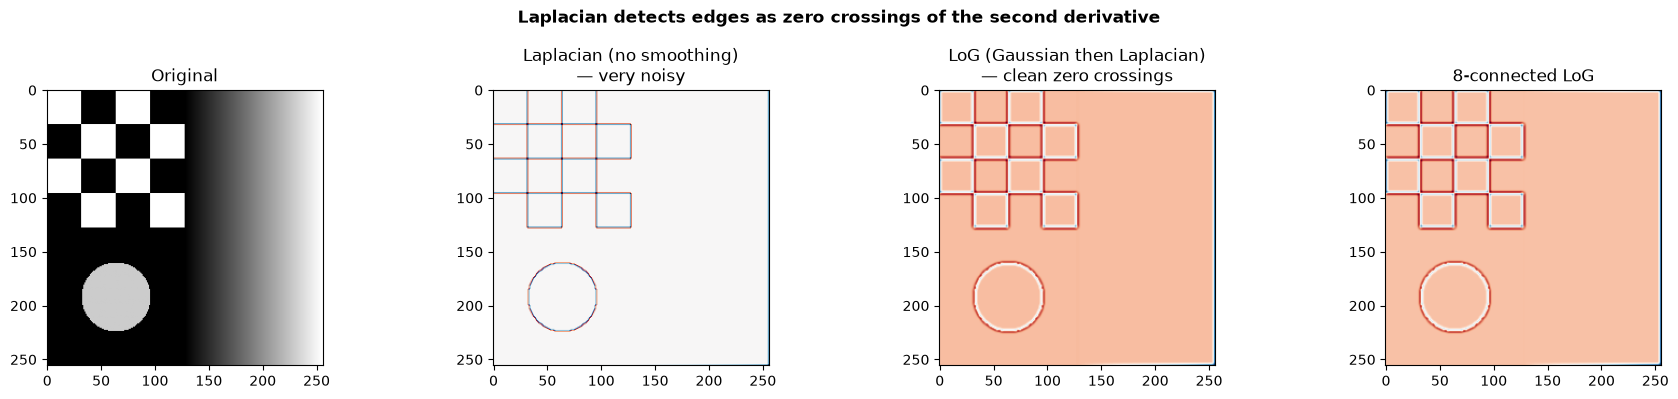

In [8]:
laplacian_4 = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=np.float64)

laplacian_8 = np.array([[1, 1, 1], [1, -8, 1], [1, 1, 1]], dtype=np.float64)

G_smooth = gaussian_kernel(5, 1.0)
smoothed_img = convolve2d(test_img.astype(np.float64), G_smooth)

lap_raw = convolve2d(test_img.astype(np.float64), laplacian_4)
lap_smooth = convolve2d(smoothed_img, laplacian_4)
lap_8conn = convolve2d(smoothed_img, laplacian_8)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].imshow(test_img, cmap="gray")
axes[0].set_title("Original")
axes[1].imshow(lap_raw, cmap="RdBu_r")
axes[1].set_title("Laplacian (no smoothing)\n— very noisy")
axes[2].imshow(lap_smooth, cmap="RdBu_r")
axes[2].set_title("LoG (Gaussian then Laplacian)\n— clean zero crossings")
axes[3].imshow(lap_8conn, cmap="RdBu_r")
axes[3].set_title("8-connected LoG")
plt.suptitle(
    "Laplacian detects edges as zero crossings of the second derivative",
    fontweight="bold",
)
plt.tight_layout()
plt.show()

---
## 5. Edge Detection — Canny Algorithm

The **Canny edge detector** (Canny, *IEEE TPAMI*, 1986) remains the gold standard for
edge detection after nearly four decades. Canny formulated edge detection as an
**optimal filtering problem** with three criteria:

1. **Good detection** — low probability of missing real edges or marking false edges
2. **Good localisation** — detected edge should be as close as possible to the true edge
3. **Single response** — only one response to a single edge (no double counting)

He proved that the optimal 1D filter approximating all three criteria is the
**first derivative of a Gaussian** — which is why the Canny algorithm begins with
Gaussian smoothing followed by gradient computation.

### The Four Stages

### Stage 1: Gaussian Smoothing

Convolve the image with a 2D Gaussian kernel to suppress noise:

$$G(x, y) = \frac{1}{2\pi\sigma^2} \exp\!\left(-\frac{x^2 + y^2}{2\sigma^2}\right)$$

$$I_\text{smooth} = G * I$$

Larger \(\sigma\) produces fewer edges (more smoothing). Canny's original analysis showed
\(\sigma \approx 1.0\) offers the best trade-off between detection and localisation.

### Stage 2: Gradient Computation

Apply Sobel operators to compute partial derivatives:

$$G_x = \begin{bmatrix} -1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1 \end{bmatrix} * I_\text{smooth}, \qquad G_y = \begin{bmatrix} -1 & -2 & -1 \\ 0 & 0 & 0 \\ 1 & 2 & 1 \end{bmatrix} * I_\text{smooth}$$

Then compute the gradient magnitude and direction at each pixel:

$$M(x,y) = \sqrt{G_x^2 + G_y^2}, \qquad \theta(x,y) = \text{atan2}(G_y, G_x)$$

### Stage 3: Non-Maximum Suppression (NMS)

Thin edges to 1-pixel width. For each pixel \((x, y)\):
1. Quantise \(\theta(x,y)\) to the nearest 45° (0°, 45°, 90°, 135°)
2. Interpolate the magnitude at the two neighbours along that direction
3. If \(M(x,y)\) is not the local maximum along \(\theta\), suppress it: \(M(x,y) \leftarrow 0\)

This produces thin, well-localised edges (one of Canny's three optimality criteria).

### Stage 4: Double Thresholding + Hysteresis

Given thresholds \(\tau_\text{high}\) and \(\tau_\text{low}\) (typically \(\tau_\text{high} \approx 2\text{–}3 \times \tau_\text{low}\)):

$$\text{pixel}(x,y) = \begin{cases} \textbf{strong} & \text{if } M(x,y) > \tau_\text{high} \\ \textbf{weak} & \text{if } \tau_\text{low} < M(x,y) \leq \tau_\text{high} \\ \textbf{suppressed} & \text{if } M(x,y) \leq \tau_\text{low} \end{cases}$$

Weak edges connected (8-connectivity) to strong edges are promoted to strong; isolated
weak edges are removed. This bridges gaps in edge contours while rejecting noise.

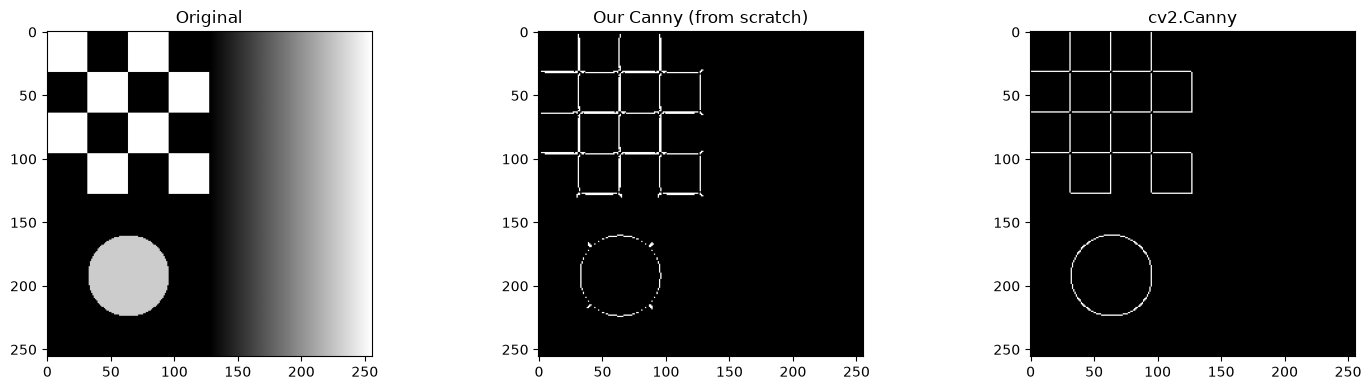

In [9]:
def canny_edges(
    image: np.ndarray, low_thresh: float, high_thresh: float, sigma: float = 1.4
) -> np.ndarray:
    """
    Canny edge detector implemented from scratch.

    Algorithm:
    1. Gaussian smoothing with parameter σ
    2. Gradient computation (Sobel)
    3. Non-maximum suppression along gradient direction
    4. Double thresholding + hysteresis edge tracking

    Parameters
    ----------
    image : (H, W) grayscale float image
    low_thresh : lower threshold for hysteresis
    high_thresh : upper threshold for hysteresis
    sigma : Gaussian smoothing parameter

    Returns
    -------
    edges : (H, W) binary edge map
    """
    H, W = image.shape

    # Stage 1: Gaussian smoothing
    ksize = max(3, int(np.ceil(6 * sigma)) | 1)
    G = gaussian_kernel(ksize, sigma)
    smoothed = convolve2d(image.astype(np.float64), G)

    # Stage 2: Gradient computation
    _gx, _gy, magnitude, direction = sobel_gradients(smoothed)

    # Stage 3: Non-maximum suppression
    # Quantize gradient direction to 4 orientations (0°, 45°, 90°, 135°)
    angle = direction * 180.0 / np.pi
    angle[angle < 0] += 180.0

    nms = np.zeros_like(magnitude)
    for i in range(1, H - 1):
        for j in range(1, W - 1):
            # Determine neighbor pixels along gradient direction
            a = angle[i, j]
            m = magnitude[i, j]

            if (0 <= a < 22.5) or (157.5 <= a <= 180):  # 0°: horizontal edge
                n1, n2 = magnitude[i, j - 1], magnitude[i, j + 1]
            elif 22.5 <= a < 67.5:  # 45°: diagonal
                n1, n2 = magnitude[i - 1, j + 1], magnitude[i + 1, j - 1]
            elif 67.5 <= a < 112.5:  # 90°: vertical edge
                n1, n2 = magnitude[i - 1, j], magnitude[i + 1, j]
            else:  # 135°: diagonal
                n1, n2 = magnitude[i - 1, j - 1], magnitude[i + 1, j + 1]

            if m >= n1 and m >= n2:
                nms[i, j] = m

    # Stage 4: Double thresholding + hysteresis
    strong = nms >= high_thresh
    weak = (nms >= low_thresh) & (~strong)

    # Hysteresis: weak pixels connected to strong pixels survive
    edges = strong.copy()
    changed = True
    while changed:
        changed = False
        for i in range(1, H - 1):
            for j in range(1, W - 1):
                if (
                    weak[i, j]
                    and not edges[i, j]
                    and edges[i - 1 : i + 2, j - 1 : j + 2].any()
                ):
                    edges[i, j] = True
                    changed = True

    return edges.astype(np.float64)


our_canny = canny_edges(test_img, low_thresh=0.05, high_thresh=0.15, sigma=1.4)
cv2_canny = cv2.Canny((test_img * 255).astype(np.uint8), 50, 150) / 255.0

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(test_img)
axes[0].set_title("Original")
axes[1].imshow(our_canny)
axes[1].set_title("Our Canny (from scratch)")
axes[2].imshow(cv2_canny)
axes[2].set_title("cv2.Canny")
plt.tight_layout()
plt.show()

---
## 6. Image Pyramids and Scale Space

### The Scale Problem

A fixed-size kernel can only detect features at one scale. A corner that's 5 pixels
wide needs a different kernel than one that's 50 pixels wide. **Scale space theory**
(Koenderink 1984, Lindeberg 1994) provides the solution.

### Gaussian Pyramid

Repeatedly blur and downsample by factor 2:

$$
L_0 = I, \quad L_{l+1} = \text{downsample}(G_\sigma * L_l)
$$

Each level represents the image at a coarser scale. Resolution halves at each level.

### Laplacian Pyramid

The **difference** between consecutive Gaussian levels (after upsampling to match):

$$
\text{Lap}_l = L_l - \text{upsample}(L_{l+1})
$$

Each Laplacian level captures the **band-pass** detail at that scale.
The original image can be perfectly reconstructed from the Laplacian pyramid:

$$
L_l = \text{Lap}_l + \text{upsample}(L_{l+1})
$$

### Scale Space and the Heat Equation

Continuous scale space defines \(L(x, t) = G(\cdot\,; \sqrt{t}) * I\) where \(t = \sigma^2\).
To derive the PDE governing scale space, we change variables from \(\sigma\) to \(t = \sigma^2\)
using the chain rule and the heat equation \(\frac{\partial G}{\partial \sigma} = \sigma\,\nabla^2 G\)
(proved in Section 4):

$$
\frac{\partial G}{\partial t}
= \frac{\partial G}{\partial \sigma}\,\frac{d\sigma}{dt}
= \sigma\,\nabla^2 G \;\cdot\; \frac{1}{2\sigma}
= \frac{1}{2}\nabla^2 G
$$

Since convolution commutes with differentiation, \(\frac{\partial L}{\partial t} = \frac{\partial G}{\partial t} * I = \frac{1}{2}\nabla^2 G * I = \frac{1}{2}\nabla^2 L\):

$$
\boxed{\frac{\partial L}{\partial t} = \frac{1}{2}\nabla^2 L}
$$

This is the **heat (diffusion) equation**. The Gaussian is its unique Green's function
satisfying non-creation of local extrema (Koenderink 1984) — i.e., Gaussian blurring is
the *only* linear smoothing that never introduces spurious structure at coarser scales.

### Why This Matters
- **SIFT** detects features across scales using a Difference-of-Gaussians pyramid
- **Feature Pyramid Networks (FPN)** in deep learning use the same multi-scale idea
- **Depth estimation** networks output at multiple resolutions

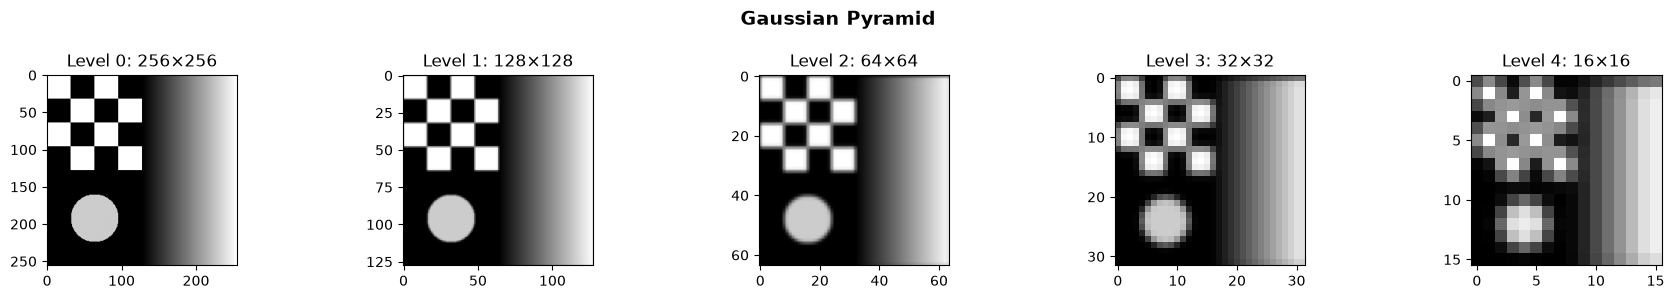

In [10]:
def build_gaussian_pyramid(image: np.ndarray, levels: int) -> list[np.ndarray]:
    """
    Build a Gaussian pyramid by repeated blur + downsample.

    Level 0 = original image.
    Level l+1 = downsample(G_σ * Level_l) by factor 2.

    Parameters
    ----------
    image : (H, W) grayscale image
    levels : number of pyramid levels (including original)

    Returns
    -------
    pyramid : list of arrays, pyramid[0] = original
    """
    pyramid = [image.astype(np.float64)]
    G = gaussian_kernel(5, 1.0)

    for _ in range(levels - 1):
        blurred = convolve2d(pyramid[-1], G)
        downsampled = blurred[::2, ::2]  # subsample by 2
        pyramid.append(downsampled)

    return pyramid


def build_laplacian_pyramid(image: np.ndarray, levels: int) -> list[np.ndarray]:
    """
    Build a Laplacian pyramid.

    Lap_l = G_l - upsample(G_{l+1})

    The last level is the smallest Gaussian level (residual).

    Returns
    -------
    laplacian : list of arrays. laplacian[-1] = smallest Gaussian level.
    """
    gauss_pyr = build_gaussian_pyramid(image, levels)
    laplacian = []

    for i in range(len(gauss_pyr) - 1):
        h, w = gauss_pyr[i].shape
        # Upsample the next level to match current level's size
        upsampled = np.zeros((h, w), dtype=np.float64)
        small = gauss_pyr[i + 1]
        sh, sw = small.shape
        upsampled[: sh * 2 : 2, : sw * 2 : 2] = small
        # Smooth the upsampled image
        G = gaussian_kernel(5, 1.0)
        upsampled_smooth = convolve2d(upsampled, G) * 4  # scale factor for energy
        upsampled_smooth = upsampled_smooth[:h, :w]

        laplacian.append(gauss_pyr[i] - upsampled_smooth)

    laplacian.append(gauss_pyr[-1])  # residual (smallest Gaussian level)
    return laplacian


def reconstruct_from_laplacian(laplacian: list[np.ndarray]) -> np.ndarray:
    """Reconstruct image from Laplacian pyramid: L_l = Lap_l + upsample(L_{l+1})."""
    current = laplacian[-1].copy()

    for i in range(len(laplacian) - 2, -1, -1):
        h, w = laplacian[i].shape
        upsampled = np.zeros((h, w), dtype=np.float64)
        sh, sw = current.shape
        upsampled[: sh * 2 : 2, : sw * 2 : 2] = current
        G = gaussian_kernel(5, 1.0)
        upsampled_smooth = convolve2d(upsampled, G) * 4
        upsampled_smooth = upsampled_smooth[:h, :w]
        current = laplacian[i] + upsampled_smooth

    return current


gauss_pyr = build_gaussian_pyramid(test_img, 5)

fig, axes = plt.subplots(1, 5, figsize=(18, 3))
for i, (ax, level) in enumerate(zip(axes, gauss_pyr, strict=False)):
    ax.imshow(level, cmap="gray")
    ax.set_title(f"Level {i}: {level.shape[1]}×{level.shape[0]}")
fig.suptitle("Gaussian Pyramid", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

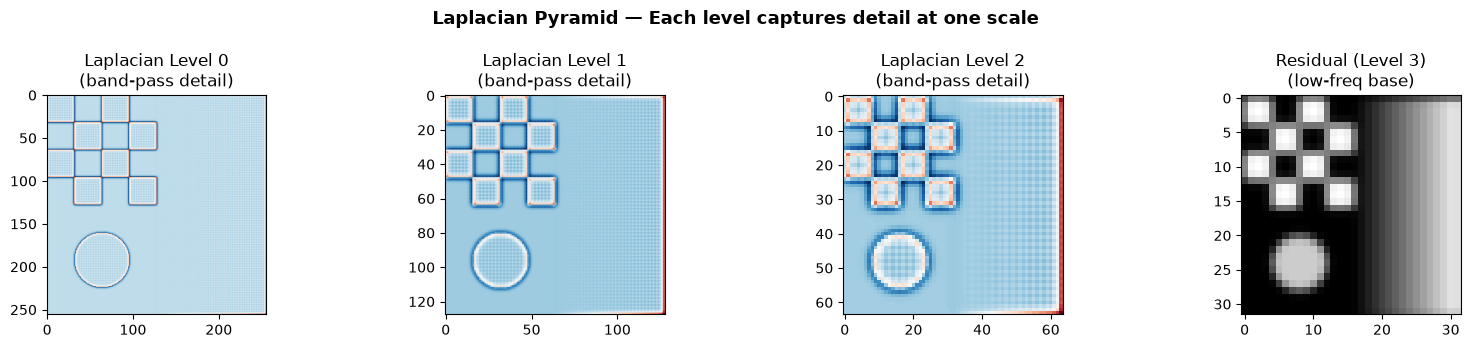

Laplacian pyramid reconstruction error: 2.22e-16
(Should be near machine epsilon ≈ 2.2e-16 for perfect reconstruction)


In [11]:
lap_pyr = build_laplacian_pyramid(test_img, 4)

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for i, (ax, level) in enumerate(zip(axes, lap_pyr, strict=False)):
    if i < len(lap_pyr) - 1:
        ax.imshow(level, cmap="RdBu_r")
        ax.set_title(f"Laplacian Level {i}\n(band-pass detail)")
    else:
        ax.imshow(level, cmap="gray")
        ax.set_title(f"Residual (Level {i})\n(low-freq base)")
fig.suptitle(
    "Laplacian Pyramid — Each level captures detail at one scale",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

# Verify reconstruction
reconstructed = reconstruct_from_laplacian(lap_pyr)
reconstruction_error = np.max(np.abs(test_img.astype(np.float64) - reconstructed))
print(f"Laplacian pyramid reconstruction error: {reconstruction_error:.2e}")
print("(Should be near machine epsilon ≈ 2.2e-16 for perfect reconstruction)")

---
## 7. Morphological Operations

Morphological operations work on binary or grayscale images using a **structuring
element** (SE), typically a small disk or square.

| Operation | Definition | Effect |
|-----------|-----------|--------|
| **Erosion** | \(\min\) over SE neighborhood | Shrinks bright regions, removes small objects |
| **Dilation** | \(\max\) over SE neighborhood | Grows bright regions, fills small holes |
| **Opening** | Erosion → Dilation | Removes small objects, preserves shape |
| **Closing** | Dilation → Erosion | Fills small holes, preserves shape |

### Why This Matters for 3D Mapping
- Depth maps from neural networks have holes and noise
- Morphological closing fills small depth holes
- Opening removes isolated noisy depth values
- Used in preprocessing before TSDF fusion (Notebook 12)

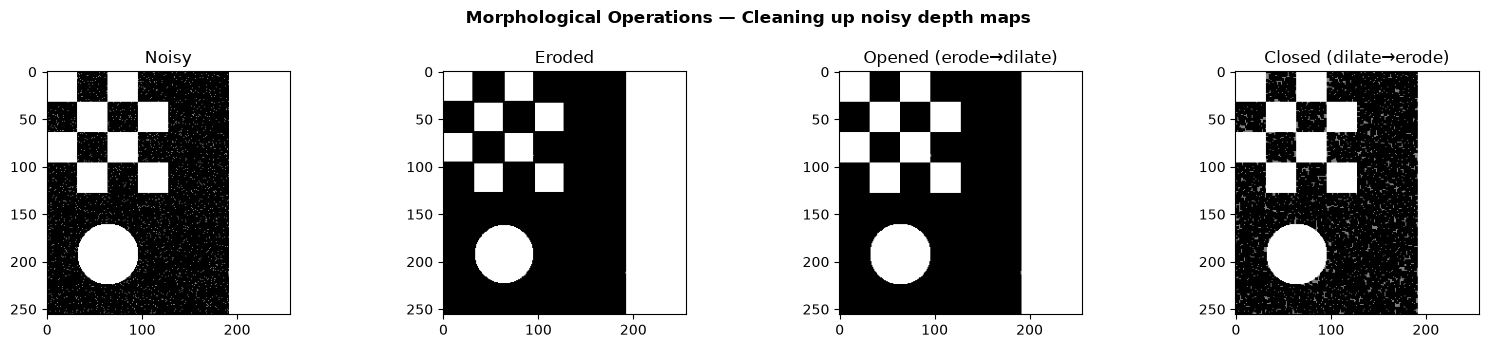

In [12]:
def erode(image: np.ndarray, se_size: int = 3) -> np.ndarray:
    """Morphological erosion: output(x,y) = min over structuring element."""
    k = se_size // 2
    padded = np.pad(image, k, mode="edge")
    H, W = image.shape
    result = np.zeros_like(image)
    for i in range(H):
        for j in range(W):
            result[i, j] = padded[i : i + se_size, j : j + se_size].min()
    return result


def dilate(image: np.ndarray, se_size: int = 3) -> np.ndarray:
    """Morphological dilation: output(x,y) = max over structuring element."""
    k = se_size // 2
    padded = np.pad(image, k, mode="edge")
    H, W = image.shape
    result = np.zeros_like(image)
    for i in range(H):
        for j in range(W):
            result[i, j] = padded[i : i + se_size, j : j + se_size].max()
    return result


binary = (test_img > 0.5).astype(np.float64)
noise = np.random.random(binary.shape) > 0.95
noisy = np.clip(binary + noise * 0.5, 0, 1)

opened = dilate(erode(noisy, 3), 3)  # opening = erode then dilate
closed = erode(dilate(noisy, 3), 3)  # closing = dilate then erode

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, im, title in zip(
    axes,
    [noisy, erode(noisy, 3), opened, closed],
    ["Noisy", "Eroded", "Opened (erode→dilate)", "Closed (dilate→erode)"],
    strict=False,
):
    ax.imshow(im, cmap="gray")
    ax.set_title(title)
plt.suptitle(
    "Morphological Operations — Cleaning up noisy depth maps", fontweight="bold"
)
plt.tight_layout()
plt.show()

---
## 8. Exercises

### Exercise 1: Vectorized Convolution
The `convolve2d` implementation above uses explicit loops and is slow.
Implement a version using `np.lib.stride_tricks.sliding_window_view` for a
~100× speedup. Verify it gives the same result.

In [13]:
def convolve2d_fast(image: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    """Vectorized 2D convolution using sliding_window_view."""
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2
    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode="constant")

    # Create a view of all patches — no memory copy!
    windows = np.lib.stride_tricks.sliding_window_view(padded, (kh, kw))
    # windows shape: (H, W, kh, kw)
    return np.einsum("ijkl,kl->ij", windows, kernel)


# Benchmark
import time

small_img = test_img[:64, :64]  # use small image for loop version
kernel_bench = gaussian_kernel(5, 1.0)

t0 = time.time()
r1 = convolve2d(small_img, kernel_bench)
t_loop = time.time() - t0

t0 = time.time()
r2 = convolve2d_fast(small_img, kernel_bench)
t_fast = time.time() - t0

print(f"Loop version: {t_loop:.3f}s")
print(f"Vectorized:   {t_fast:.4f}s")
print(f"Speedup:      {t_loop / t_fast:.0f}×")
print(f"Max diff:     {np.max(np.abs(r1 - r2)):.2e}")

Loop version: 0.009s
Vectorized:   0.0004s
Speedup:      24×
Max diff:     2.80e-08


### Exercise 2: Separable Convolution
The Gaussian kernel is **separable**: \(G_{2D} = G_{1D}^T \cdot G_{1D}\).
Implement separable convolution and show it produces the same result
as the full 2D version but with fewer operations.

For a \(k \times k\) kernel on an \(n\)-pixel image:
- Full 2D: \(n \cdot k^2\) multiplications
- Separable: \(n \cdot 2k\) multiplications

In [14]:
def convolve2d_separable(image: np.ndarray, kernel_1d: np.ndarray) -> np.ndarray:
    """Separable convolution: convolve with 1D kernel horizontally, then vertically."""
    row_kernel = kernel_1d.reshape(1, -1)  # (1, k)
    col_kernel = kernel_1d.reshape(-1, 1)  # (k, 1)
    temp = convolve2d_fast(image, row_kernel)
    return convolve2d_fast(temp, col_kernel)


G_2d = gaussian_kernel(11, 2.0)
G_1d = G_2d[5, :]  # middle row — the 1D Gaussian
G_1d = G_1d / G_1d.sum()  # normalize

result_2d = convolve2d_fast(test_img, G_2d)
result_sep = convolve2d_separable(test_img, G_1d)

print(f"Max difference (2D vs separable): {np.max(np.abs(result_2d - result_sep)):.2e}")
print(
    f"Operations for 11×11 kernel: 2D = {11 * 11} = 121 per pixel, separable = {2 * 11} = 22 per pixel"
)
print(f"Savings: {(1 - 22 / 121) * 100:.0f}%")

Max difference (2D vs separable): 4.44e-16
Operations for 11×11 kernel: 2D = 121 = 121 per pixel, separable = 22 = 22 per pixel
Savings: 82%


### Exercise 3: Scale-Dependent Corner Detection

A corner is only detectable when the kernel is at the right scale.
Show this by detecting corners at different pyramid levels.

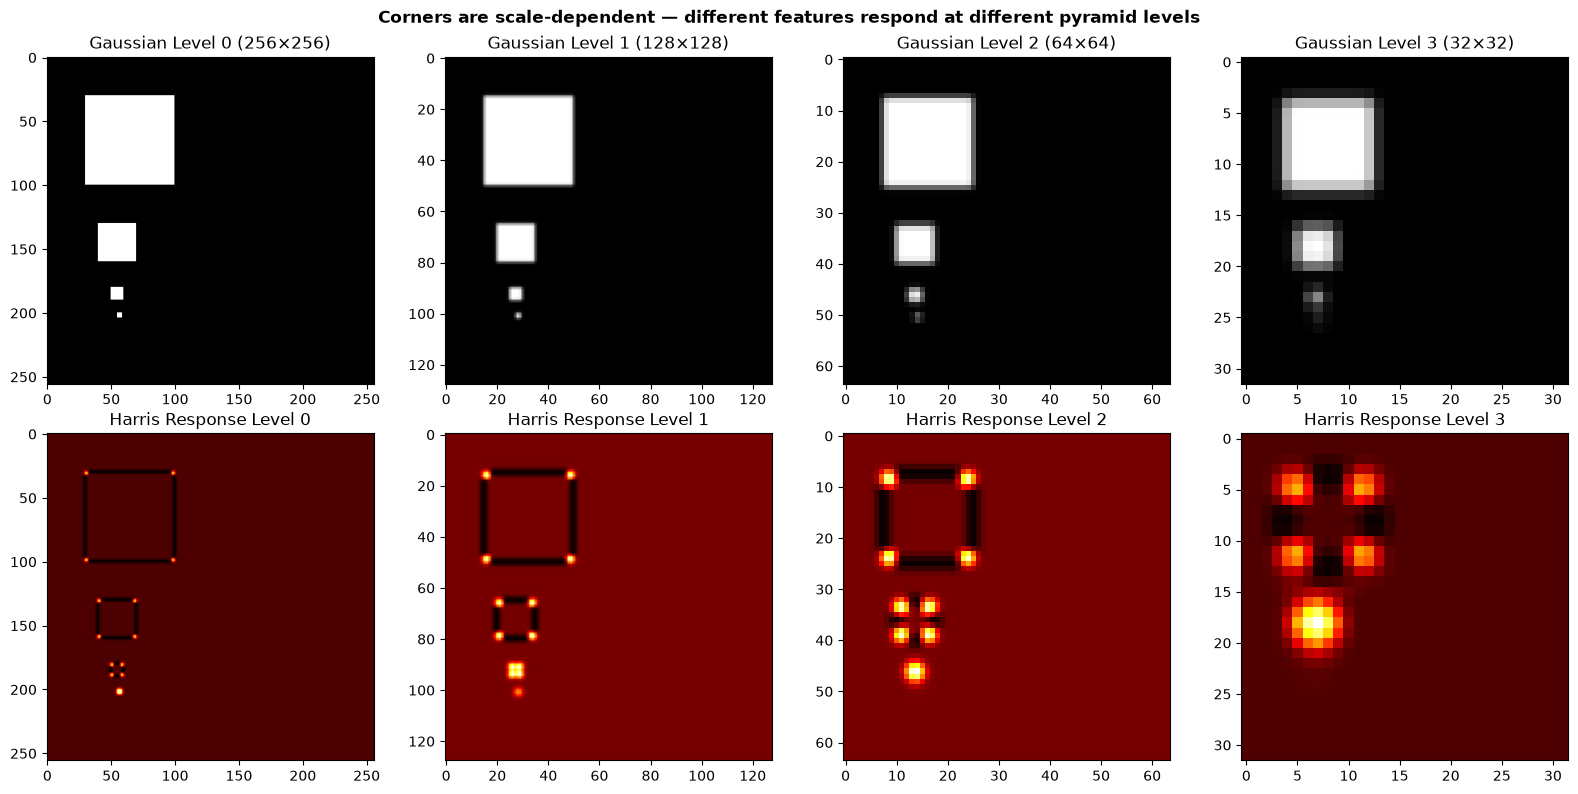

In [15]:
multi_scale = np.zeros((256, 256), dtype=np.float64)
# Large square (detectable at coarse scale)
multi_scale[30:100, 30:100] = 1.0
# Medium square
multi_scale[130:160, 40:70] = 1.0
# Small square
multi_scale[180:190, 50:60] = 1.0
# Tiny square
multi_scale[200:204, 55:59] = 1.0

gauss_pyr = build_gaussian_pyramid(multi_scale, 4)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, level in enumerate(gauss_pyr):
    # Harris corner response at this level
    gx, gy, _, _ = sobel_gradients(level)
    Ixx = convolve2d_fast(gx * gx, gaussian_kernel(5, 1.5))
    Iyy = convolve2d_fast(gy * gy, gaussian_kernel(5, 1.5))
    Ixy = convolve2d_fast(gx * gy, gaussian_kernel(5, 1.5))
    det = Ixx * Iyy - Ixy**2
    trace = Ixx + Iyy
    harris = det - 0.04 * trace**2  # Harris corner response

    axes[0, i].imshow(level, cmap="gray")
    axes[0, i].set_title(f"Gaussian Level {i} ({level.shape[1]}×{level.shape[0]})")
    axes[1, i].imshow(harris, cmap="hot")
    axes[1, i].set_title(f"Harris Response Level {i}")

fig.suptitle(
    "Corners are scale-dependent — different features respond at different pyramid levels",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

---
## Summary & Connections to Later Notebooks

| Concept | Where It Appears Later |
|---------|----------------------|
| Convolution | CNN layers in depth estimation (NB 09), feature extraction (NB 05) |
| Gaussian blur | Scale space in SIFT (NB 05), Gaussian pyramid in FPN |
| Gradients | Harris/FAST corner detection (NB 05), optical flow (NB 06) |
| Edge detection | Feature detection preprocessing |
| Image pyramids | Multi-scale feature detection (NB 05), coarse-to-fine VO (NB 07) |
| Morphology | Depth map cleanup before TSDF fusion (NB 12) |

### Key Takeaways

1. **Convolution is the fundamental operation** of both classical CV and deep learning
2. **Gaussian smoothing** is the unique scale-space kernel — it forms the basis of all
   multi-scale analysis
3. **Gradients** encode edge strength and direction — the foundation of feature detection
4. **Canny** combines four ideas: smoothing, gradients, thinning, and hysteresis
5. **Pyramids** enable scale-invariant processing — critical for real-world robustness

**Next**: Notebook 02 — Projective Geometry & Homographies